<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2FResNet50/03_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet50 - Brain Tumor MRI Classification
SE4050 Deep Learning Assignment | Transfer learning with ResNet50
Classes: 0 = Glioma, 1 = Meningioma, 2 = No Tumor, 3 = Pituitary

## 1. Environment and Configuration

In [3]:
# Connect Colab to Google Drive so we can read the shared dataset
from google.colab import drive
drive.mount('/content/drive')

PROJECT = "/content/drive/MyDrive/SE4050_DL_Assignment"
!ls "{PROJECT}/Dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset  dataset_config.py


In [4]:
PROJECT = "/content/drive/MyDrive/SE4050_DL_Assignment"
DATASET = f"{PROJECT}/Dataset/dataset"

# Check the folder structure
!ls "{DATASET}"
!ls "{DATASET}/splits"


splits	Testing  Training
test.csv  test.gsheet  train.csv  train.gsheet	val.csv


In [5]:
# Common training settings and helper functions: seed, image size, shared augmentation and the
# training strategy (max 10 epochs, early stopping on val_loss, best model saved). These match the
# proposed group common_config.py, so once it is finalized this cell becomes: from common_config import *
import os, random, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
MAX_EPOCHS = 10
NUM_CLASSES = 4
CLASS_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]   # index = label (0-3)
EARLY_STOPPING_PATIENCE = 3

def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

def build_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.05, seed=SEED),
        tf.keras.layers.RandomZoom(0.1, seed=SEED),
    ], name="augmentation")

def train_model(model, train_ds, val_ds, checkpoint_path, history_path):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss",
                                           save_best_only=True, verbose=1),
    ]
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS, callbacks=callbacks)
    minutes = (time.time() - start) / 60
    pd.DataFrame(history.history).to_csv(history_path, index=False)
    best = int(np.argmin(history.history["val_loss"])) + 1
    print(f"Training time: {minutes:.1f} min | Epochs run: {len(history.history['loss'])} | Best epoch: {best}")
    print(f"Best val_loss: {min(history.history['val_loss']):.4f} | "
          f"val_accuracy at best epoch: {history.history['val_accuracy'][best - 1]:.4f}")
    return history, minutes

set_seeds()
MODELS_DIR  = f"{PROJECT}/Trained Models"
RESULTS_DIR = f"{PROJECT}/Results/ResNet50"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Image size:", IMG_SIZE, "| Batch:", BATCH_SIZE, "| Max epochs:", MAX_EPOCHS, "| Seed:", SEED)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Image size: (224, 224) | Batch: 16 | Max epochs: 10 | Seed: 42


## 2. Dataset and Data Splits

In [6]:
#Load shared split CSV files
import pandas as pd

train_df = pd.read_csv(f"{DATASET}/splits/train.csv")
val_df   = pd.read_csv(f"{DATASET}/splits/val.csv")
test_df  = pd.read_csv(f"{DATASET}/splits/test.csv")

print(len(train_df), len(val_df), len(test_df))
print(train_df.columns.tolist())
print(train_df.head())

4480 1120 1600
['filepath', 'label', 'class_name']
                           filepath  label class_name
0  Training/pituitary/Tr-pi_135.jpg      3  Pituitary
1    Training/notumor/Tr-no_154.jpg      2   No Tumor
2     Training/glioma/Tr-gl_365.jpg      0     Glioma
3  Training/pituitary/Tr-pi_125.jpg      3  Pituitary
4     Training/glioma/Tr-gl_433.jpg      0     Glioma


In [7]:
#Copy images to local disk
LOCAL = "/content/data"
!mkdir -p {LOCAL}
!cp -r "{DATASET}/Training" "{DATASET}/Testing" {LOCAL}/
!ls {LOCAL}

Testing  Training


In [8]:
#Build full paths and verify files
import os

for df in (train_df, val_df, test_df):
    df["full_path"] = LOCAL + "/" + df["filepath"]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = (~df["full_path"].apply(os.path.exists)).sum()
    print(f"{name}: {len(df)} images, missing files: {missing}")
    print(df["class_name"].value_counts().sort_index().to_dict())

train: 4480 images, missing files: 0
{'Glioma': 1120, 'Meningioma': 1120, 'No Tumor': 1120, 'Pituitary': 1120}
val: 1120 images, missing files: 0
{'Glioma': 280, 'Meningioma': 280, 'No Tumor': 280, 'Pituitary': 280}
test: 1600 images, missing files: 0
{'Glioma': 400, 'Meningioma': 400, 'No Tumor': 400, 'Pituitary': 400}


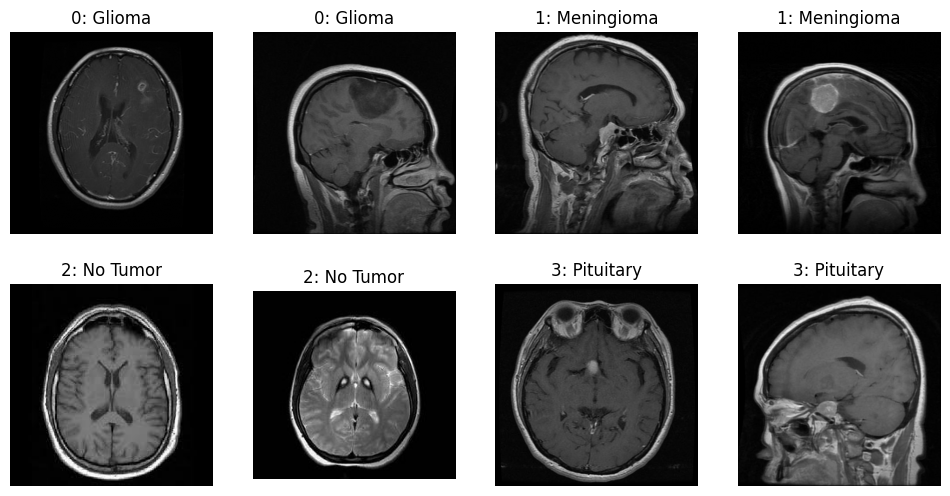

In [9]:
#Sample images per class
import matplotlib.pyplot as plt
from PIL import Image

sample = train_df.groupby("label").head(2).sort_values("label")
plt.figure(figsize=(12, 6))
for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row["full_path"]), cmap="gray")
    plt.title(f'{row["label"]}: {row["class_name"]}')
    plt.axis("off")
plt.show()

## 3. Image Preprocessing

In [10]:
# Builds the input pipeline: loads and resizes images to 224x224 and applies ResNet50's own
# preprocessing (no /255). Augmentation is inside the model, so all splits load the same way.
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return preprocess_input(img), label

def make_ds(df, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((df["full_path"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, shuffle=True)
val_ds   = make_ds(val_df, shuffle=False)
test_ds  = make_ds(test_df, shuffle=False)

x, y = next(iter(train_ds))
print("Batch shape:", x.shape, "| Labels:", y.numpy())

Batch shape: (16, 224, 224, 3) | Labels: [2 3 1 2 0 2 2 1 3 2 3 1 2 1 1 2]


## 4. ResNet50 Model

In [13]:
# ResNet50 pretrained on ImageNet with a frozen backbone. The shared augmentation layer comes first
# (active only during training), followed by a new head: pooling, dropout, 4-class softmax.
tf.keras.backend.clear_session()
set_seeds()

base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = build_augmentation()(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs, name="resnet50_brain_mri")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "resnet50_brain_mri"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 5. Model Training

In [14]:
# Stage 1: trains only the new head (backbone frozen): max 10 epochs, early stopping on val_loss
# (patience 3), best model and training history saved to Drive.
history1, stage1_minutes = train_model(
    model, train_ds, val_ds,
    checkpoint_path=f"{MODELS_DIR}/resnet50_stage1.keras",
    history_path=f"{RESULTS_DIR}/history_stage1.csv",
)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6599 - loss: 0.8980
Epoch 1: val_loss improved from None to 0.36937, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 54s 149ms/step - accuracy: 0.7679 - loss: 0.6147 - val_accuracy: 0.8580 - val_loss: 0.3694
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8512 - loss: 0.3795
Epoch 2: val_loss improved from 0.36937 to 0.31926, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.8580 - loss: 0.3659 - val_accuracy: 0.8795 - val_loss: 0.3193
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accu

In [15]:
# Stage 2 (fine-tuning, extra experiment): loads the best Stage 1 model from Drive (works even after
# a runtime restart), unfreezes the conv5 block (BatchNorm stays frozen) and trains with lr = 1e-5.
model = tf.keras.models.load_model(f"{MODELS_DIR}/resnet50_stage1.keras")
base = model.get_layer("resnet50")

base.trainable = True
for layer in base.layers:
    layer.trainable = layer.name.startswith("conv5") and not isinstance(layer, tf.keras.layers.BatchNormalization)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
print("Trainable params:", sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))

history2, stage2_minutes = train_model(
    model, train_ds, val_ds,
    checkpoint_path=f"{MODELS_DIR}/resnet50_finetuned.keras",
    history_path=f"{RESULTS_DIR}/history_stage2.csv",
)

Trainable params: 14961668
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9094 - loss: 0.2417
Epoch 1: val_loss improved from None to 0.18545, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 49s 141ms/step - accuracy: 0.9237 - loss: 0.2105 - val_accuracy: 0.9277 - val_loss: 0.1855
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9429 - loss: 0.1516
Epoch 2: val_loss did not improve from 0.18545
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 130ms/step - accuracy: 0.9467 - loss: 0.1412 - val_accuracy: 0.9312 - val_loss: 0.1882
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9594 - loss: 0.1052
Epoch 3: val_loss did not improve from 0.18545
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.9625 - loss: 0.1029 - val_accuracy: 0.9214 - val_

## 6. Training Results

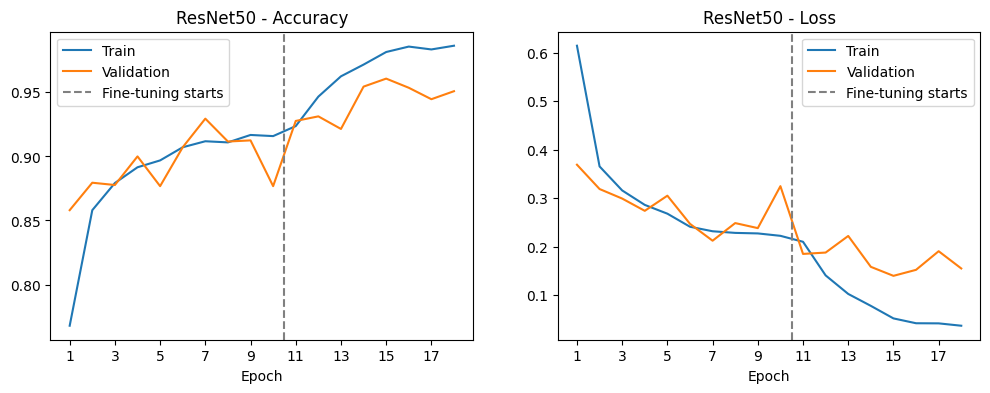

In [18]:
# Plots accuracy and loss from the saved history files (works after a restart). If Stage 2 has run,
# both stages are shown with a dashed line where fine-tuning starts. Epochs are numbered from 1.
h1 = pd.read_csv(f"{RESULTS_DIR}/history_stage1.csv")
stage2_file = f"{RESULTS_DIR}/history_stage2.csv"
h = pd.concat([h1, pd.read_csv(stage2_file)], ignore_index=True) if os.path.exists(stage2_file) else h1
epochs = range(1, len(h) + 1)

plt.figure(figsize=(12, 4))
for i, metric in enumerate(["accuracy", "loss"]):
    plt.subplot(1, 2, i + 1)
    plt.plot(epochs, h[metric], label="Train")
    plt.plot(epochs, h[f"val_{metric}"], label="Validation")
    if len(h) > len(h1):
        plt.axvline(len(h1) + 0.5, color="gray", linestyle="--", label="Fine-tuning starts")
    plt.title(f"ResNet50 - {metric.capitalize()}")
    plt.xlabel("Epoch"); plt.legend()
    plt.xticks(range(1, len(h) + 1, 2))

plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Model Evaluation

In [22]:
# Evaluates a trained model on one data split: classification report, accuracy, macro
# precision/recall/F1, ROC-AUC, confusion matrix and per-image predictions, all saved to Results.
import json
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

def evaluate_model(model, ds, df, split_name, tag):
    probs = model.predict(ds, verbose=1)
    preds = probs.argmax(axis=1)
    y = df["label"].values

    print(classification_report(y, preds, target_names=CLASS_NAMES, digits=4))
    report = classification_report(y, preds, target_names=CLASS_NAMES, output_dict=True)

    metrics = {
        "model": f"ResNet50_{tag}",
        "split": split_name,
        "accuracy": report["accuracy"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "roc_auc_ovr_macro": roc_auc_score(y, probs, multi_class="ovr", average="macro"),
        "per_class": {c: report[c] for c in CLASS_NAMES},
        "total_params": int(model.count_params()),
    }
    with open(f"{RESULTS_DIR}/metrics_{tag}_{split_name}.json", "w") as f:
        json.dump(metrics, f, indent=2)

    out = df[["filepath", "label"]].copy()
    out["pred"] = preds
    for i, c in enumerate(CLASS_NAMES):
        out[f"prob_{c}"] = probs[:, i]
    out.to_csv(f"{RESULTS_DIR}/predictions_{tag}_{split_name}.csv", index=False)

    ConfusionMatrixDisplay(confusion_matrix(y, preds), display_labels=CLASS_NAMES).plot(cmap="Blues")
    plt.title(f"ResNet50 {tag} - Confusion Matrix ({split_name})")
    plt.savefig(f"{RESULTS_DIR}/confusion_matrix_{tag}_{split_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return metrics

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step
              precision    recall  f1-score   support

      Glioma     0.9705    0.7400    0.8397       400
  Meningioma     0.8256    0.9350    0.8769       400
    No Tumor     0.9174    1.0000    0.9569       400
   Pituitary     0.9754    0.9900    0.9826       400

    accuracy                         0.9163      1600
   macro avg     0.9222    0.9163    0.9140      1600
weighted avg     0.9222    0.9163    0.9140      1600



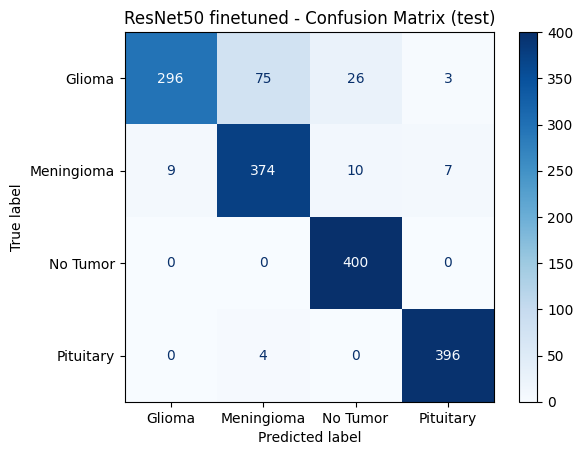

In [23]:
# Final evaluation on the untouched TEST set, run once. The fine-tuned model was chosen because it
# had the lowest validation loss; no settings are changed after seeing these results.
final_model = tf.keras.models.load_model(f"{MODELS_DIR}/resnet50_finetuned.keras")
test_metrics = evaluate_model(final_model, test_ds, test_df, split_name="test", tag="finetuned")